### Problem1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
def f(x):
    # integrand
    return np.sin(np.sqrt(100*x))**2


def Trapez(f, N, a, b):
    # Trapezoid method
    x = np.linspace(a, b, N + 1)
    h = (b - a)/N
    y = f(x)
    A = y[:-1] + y[1:]
    I = np.sum(A)*h*0.5

    return I


def Simpson(f, N, a, b):
    # Simpson's rule
    x = np.linspace(a, b, N + 1)
    h = (b - a)/N
    y = f(x)
    A = y[:-2:2] + y[2::2] + 4*y[1:-1:2]
    I = np.sum(A)*h/3

    return I

0.147979484546652
0.3252319078064746
0.5122828507233315
0.40299744847824825
0.4301033692947469
0.4484146657874699
0.45391293121537585
0.45534850437280217
0.45571126645324106
0.4558021996516641
0.45582494813242014
0.45583063620164616
0.4558320582782708
0.45583241380113443
0.455832502682082
0.4558325249023334


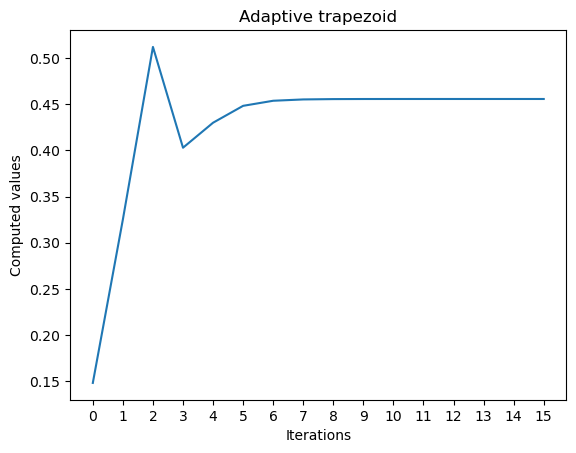

In [3]:
# 1. Adaptive trapezoid
values = np.zeros(16, dtype=float)
N = 1

for i in range(16):
    I = Trapez(f, N, 0, 1)
    values[i] = I
    print(I)
    N *= 2

plt.plot(values)
plt.xticks(range(16))
plt.title('Adaptive trapezoid')
plt.xlabel('Iterations')
plt.ylabel('Computed values')
plt.show()

In [ ]:
# 2. Romberg + Adaptive trapezoid
R = np.zeros((16, 16), dtype=float) # R_ij = R[i,j], triangluar matrix
values = np.zeros(16, dtype=float)
N = 1

for i in range(0, 16):
    for j in range(0, i+1):

0.38431604889308213
0.5746331650289503
0.3665689810632206
0.4391386762335799
0.45451843128504427
0.45574568635801116
0.455827028758611
0.45583218714672064
0.4558325107178051
0.4558325309593389
0.4558325322247215
0.4558325323038124
0.4558325323087556
0.45583253230906456
0.45583253230908377
0.45583253230908505


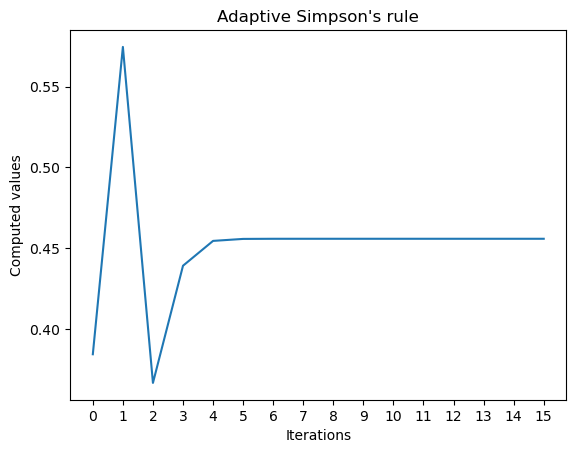

In [5]:
# 3. Simpson's rule
values = np.zeros(16, dtype=float)
N = 2

for i in range(16):
    I = Simpson(f, N, 0, 1)
    values[i] = I
    print(I)
    N *= 2

plt.plot(values)
plt.xticks(range(16))
plt.title("Adaptive Simpson's rule")
plt.xlabel('Iterations')
plt.ylabel('Computed values')
plt.show()

### Problem2

0 1.520916044886804
1 7.568086121377486
2 7.077589204505114
3 6.382659552067448
4 6.4961420455351755
5 6.4939975016871605
6 6.4939391039883745
7 6.493939060002588
8 6.493939060027927
9 6.493939060029529
10 6.4939390600296285
11 6.493939060029635
12 6.493939060029636
13 6.493939060029635
14 6.493939060029636
15 6.493939060029636
Exact value=6.493939402266828
Error=5.270101415543027e-06%


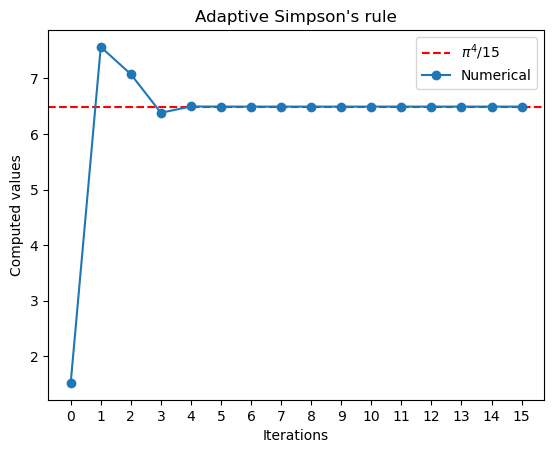

In [6]:
def f(z):
    # integrand
    x = z/(1-z)
    return x**3/(np.exp(x) - 1)/(1 - z)**2


values = np.zeros(16, dtype=float)
N = 2

for i in range(16):
    I = Simpson(f, N, 0.01, 0.99)
    values[i] = I
    print(i, I)
    N *= 2

s = np.pi**4/15
print(f"Exact value={s}")
print(f"Error={np.abs(I - s)/s*100}%")

plt.axhline(y=s, color='r', linestyle='--', label='$\pi^4/15$')
plt.plot(values, '-o', label='Numerical')
plt.xticks(range(16))
plt.title("Adaptive Simpson's rule")
plt.xlabel('Iterations')
plt.ylabel('Computed values')
plt.legend()
plt.show()


### Problem3

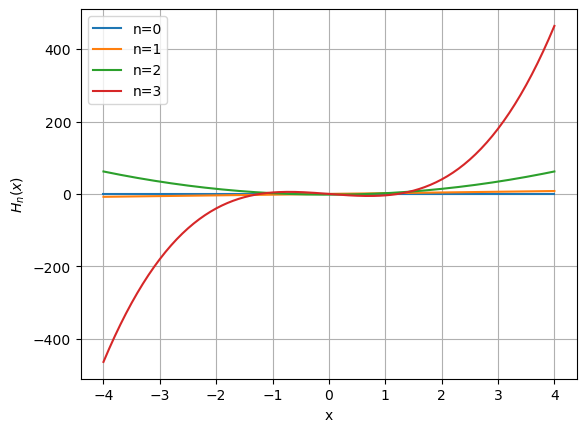

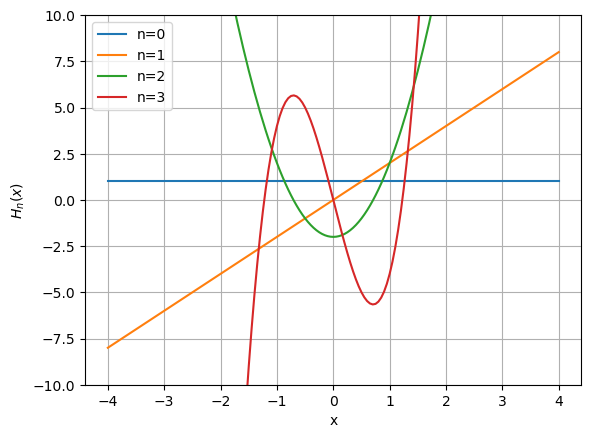

In [7]:
def H(n, x):
    # Hermite polynomial, H_n(x)
    H0 = np.ones_like(x)
    H1 = 2*x

    if n == 0: return H0
    elif n == 1: return H1
    else:
        for k in range(1, n): 
            # k = n -1
            H2 = 2*x*H1 - 2*k*H0
            H0, H1 = H1, H2

        return H1 # H2 is already sotred in H1


h = 0.05
x = np.arange(-4, 4 + h, h)

y0 = H(0, x)
y1 = H(1, x)
y2 = H(2, x)
y3 = H(3, x)


plt.plot(x, y0, label="n=0")
plt.plot(x, y1, label="n=1")
plt.plot(x, y2, label="n=2")
plt.plot(x, y3, label="n=3")
plt.xlabel('x')
plt.ylabel('$H_n(x)$')
plt.legend()
plt.grid()

plt.show()

plt.plot(x, y0, label="n=0")
plt.plot(x, y1, label="n=1")
plt.plot(x, y2, label="n=2")
plt.plot(x, y3, label="n=3")
plt.xlabel('x')
plt.ylabel('$H_n(x)$')
plt.ylim((-10, 10))
plt.legend()
plt.grid()

plt.show()

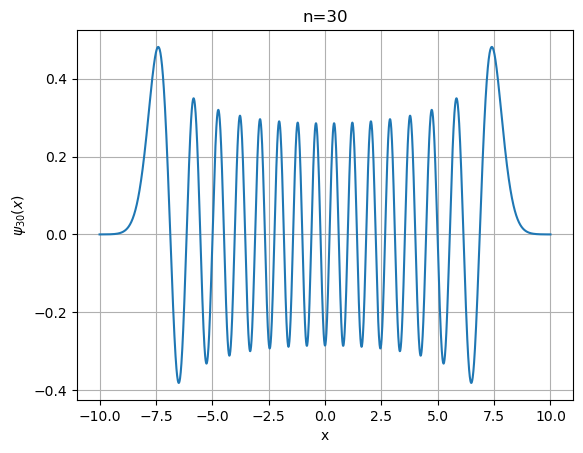

norm=0.9999999999262221


In [8]:
def factorial(n):
    f0 = 1

    if n == 0: return f0
    else:
        for k in range(1, n+1):
            f1 = k*f0
            f0 = f1

        return f0 # f2 is already sotred in f1
    

def psi(n, x):
    # Psi_n(x)
    return 1/np.sqrt(2**n*factorial(n)*np.sqrt(np.pi))*np.exp(-x*x/2)*H(n, x)

h = 0.01
x = np.arange(-10, 10 + h, h)

psi30 = psi(30, x)
norm = Simpson(lambda x:psi(30, x)*psi(30, x), 1000, -10, 10) # norm=1

plt.plot(x, psi30, label="n=30")
plt.xlabel('x')
plt.ylabel('$\\psi_{30}(x)$')
plt.title('n=30')
plt.grid()
plt.show()
print(f"norm={norm}")


In [9]:
def Gauss_quad(f, n, a, b):
    # Gaussain quadrature integrates over [a, b]
    # f: integrand
    # n: degree
    x_i = np.polynomial.legendre.legroots(np.polynomial.legendre.Legendre.basis(n).coef) # roots of P_n(x)
    P_n = np.polynomial.legendre.Legendre.basis(n) # P_n(x) polynomial
    dP_ndx = P_n.deriv()(x_i) # dP_n/dx|x=x_i

    w = (2/(1 - x_i*x_i)/dP_ndx**2)*(b - a)/2
    I = np.sum(w*f(x_i*(b - a)/2 + (b + a)/2))
    return I

I1 = Gauss_quad(lambda x:x**4 - 2*x + 1, 3, 0, 2) # I1 = 4.4
print(I1)
I2 = Gauss_quad(lambda x:psi(30, x)*psi(30, x), 100, -10, 10) # I2 = 1
print(I2)

4.399999999999999
0.9999999227013247


In [10]:
# Uncertainty
n = 5
X2 = Gauss_quad(lambda x:x*x*psi(n, x)*psi(n, x), 100, -10, 10)
print(X2)

5.50000000000003


### Problem4
Data: https://public.websites.umich.edu/~mejn/cp/programs.html

In [ ]:
def df(w, hx, hy):
    # Central difference, 1st order
    dwdx = (w[:, 2:] - w[:, :-2])/(2*hx)
    dwdy = (w[2:, :] - w[:-2, :])/(2*hy)
    return dwdx, dwdy


def I(phi, dwdx, dwdy):
    intensity = (-np.cos(phi) - np.sin(phi))/np.sqrt(dwdx[1:-1,:]**2+ dwdy[:, 1:-1]**2 + 1)

    return intensity


def dataload(filename):
    with open(filename, "r") as file:
        lines = file.readlines()

    Ny = len(lines)
    Nx = len([float(x) for x in lines[0].strip().split(' ')])

    w = np.zeros((Ny, Nx), dtype=float)

    for i, line in enumerate(lines):
        x = [float(x) for x in line.strip().split(' ')]
        w[i] = x

    return w

def imPlot(img, title):
    ax = plt.gca() 
    im = ax.imshow(img)
    ax.set_title(title)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2%", pad=0.1)
    plt.colorbar(im, cax=cax)
    plt.show()

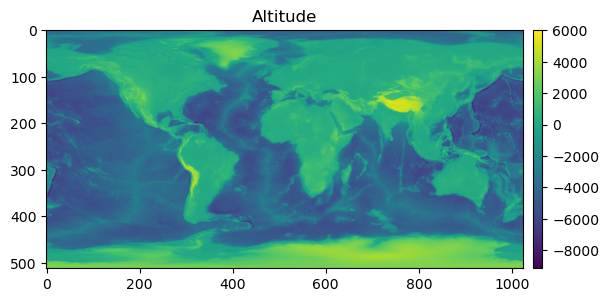

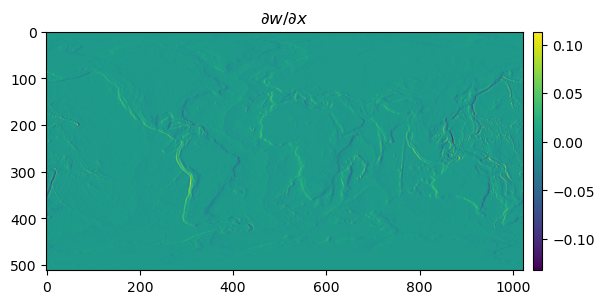

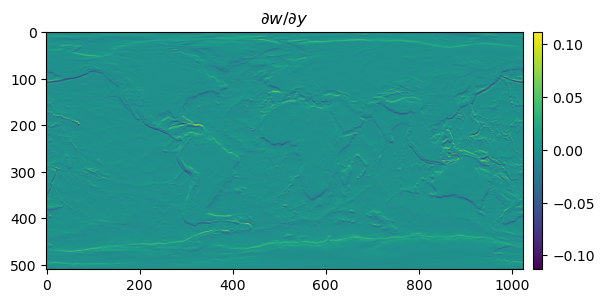

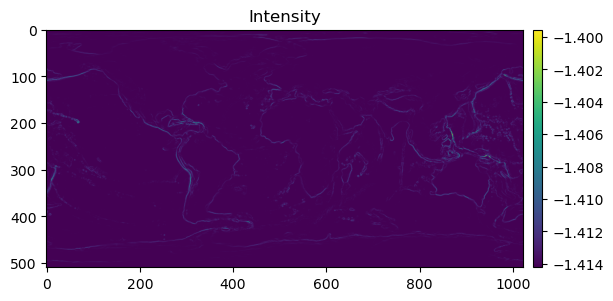

Maximum intensity=-1.3995474688856935
Minimum intensity=-1.4142135623730951


In [12]:
# 1. Surface of the earth
w = dataload("altitude.txt") # This file contains the altitude w(x,y) in meters above sea level of the surface of the earth.
dwdx, dwdy = df(w, 30000, 30000) 
I_earth = I(np.pi/4, dwdx, dwdy)

imPlot(w, "Altitude")
imPlot(dwdx,"$\\partial w/\\partial x$")
imPlot(dwdy, "$\\partial w/\\partial y$")
imPlot(I_earth, "Intensity")

print(f"Maximum intensity={np.max(I_earth)}")
print(f"Minimum intensity={np.min(I_earth)}")


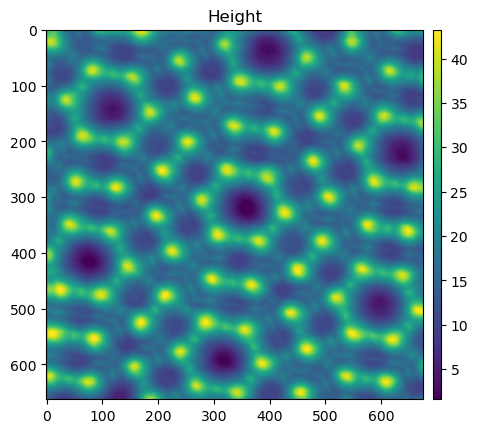

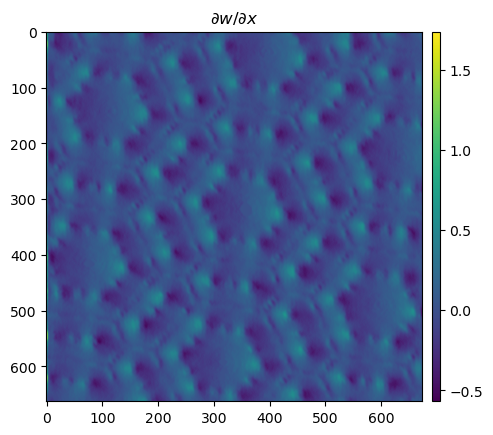

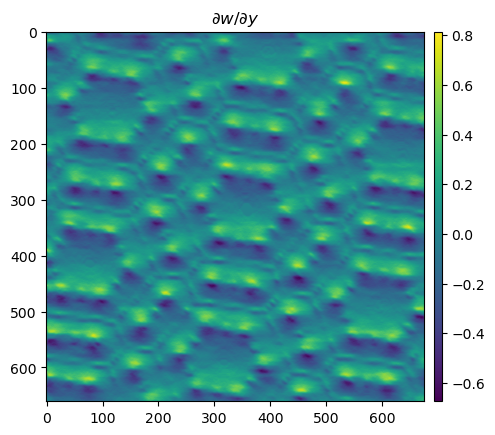

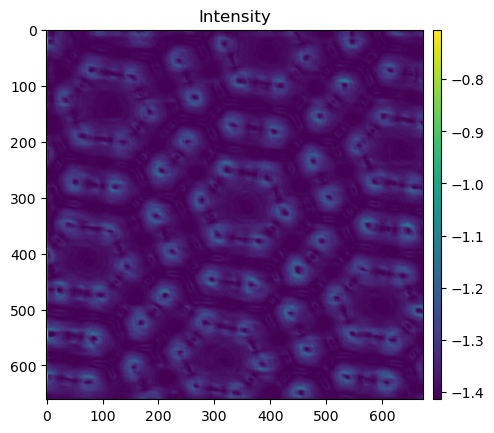

Maximum intensity=-0.7048348832760107
Minimum intensity=-1.4142135623730951


In [11]:
# 2. STM
w = dataload("stm.txt") # This file contains the STM image of the (111) surface of silicon.
dwdx, dwdy = df(w, 2.5, 2.5)
I_STM = I(np.pi/4, dwdx, dwdy)

imPlot(w, "Height")
imPlot(dwdx,"$\\partial w/\\partial x$")
imPlot(dwdy, "$\\partial w/\\partial y$")
imPlot(I_STM, "Intensity")
print(f"Maximum intensity={np.max(I_STM)}")
print(f"Minimum intensity={np.min(I_STM)}")